In [16]:
# Cell 1
import math
import numpy as np
import matplotlib.pyplot as plt
import torch

torch.manual_seed(42)

In [17]:
# Cell 2
# 평균 mu, 표준편차 sigma인 정규분포의 확률밀도함수
def normal(x, mu, sigma):
    coefficient = 1 / math.sqrt(2 * math.pi * sigma**2)
    exponent = -0.5 * ((x - mu) / sigma) ** 2
    return coefficient * np.exp(exponent)

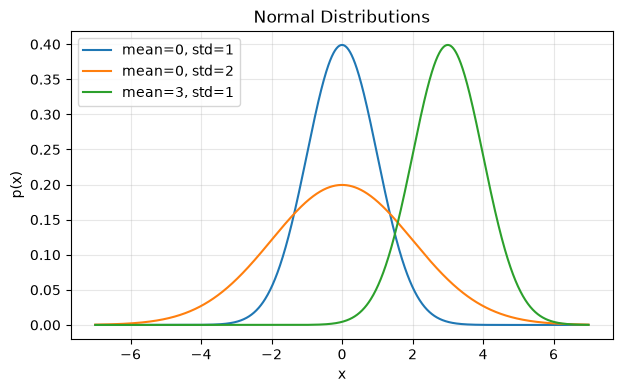

In [18]:
# Cell 3
# 평균은 곡선의 위치를, 표준편차는 곡선의 퍼짐을 결정한다.
x = np.arange(-7, 7, 0.01)
params = [(0, 1), (0, 2), (3, 1)]

plt.figure(figsize=(7, 4))

for mu, sigma in params:
    plt.plot(
        x,
        normal(x, mu, sigma),
        label=f"mean={mu}, std={sigma}",
    )

plt.xlabel("x")
plt.ylabel("p(x)")
plt.title("Normal Distributions")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [19]:
# Cell 4
# 선형회귀의 확률적 가정:
# y = Xw + b + epsilon
# epsilon ~ N(0, sigma^2)

features = torch.tensor([
    [1.0],
    [2.0],
    [3.0],
    [4.0],
])

weights = torch.tensor([[2.0]])
bias = torch.tensor([5.0])

labels = torch.tensor([
    [7.2],
    [8.8],
    [11.1],
    [12.9],
])

sigma = 1.5

predictions = features @ weights + bias
residuals = labels - predictions

print("Predictions:")
print(predictions)

print("\nResiduals:")
print(residuals)

print("\nShape:", residuals.shape)

assert predictions.shape == labels.shape == (4, 1)

Predictions:
tensor([[ 7.],
        [ 9.],
        [11.],
        [13.]])

Residuals:
tensor([[ 0.2000],
        [-0.2000],
        [ 0.1000],
        [-0.1000]])

Shape: torch.Size([4, 1])


In [20]:
# Cell 5
# Gaussian 음의 로그가능도:
# NLL = 1/2 * log(2*pi*sigma^2)
#       + residual^2 / (2*sigma^2)

nll_per_example = (
    0.5 * math.log(2 * math.pi * sigma**2)
    + residuals.pow(2) / (2 * sigma**2)
)

mean_nll = nll_per_example.mean()

# D2L의 제곱손실
mean_squared_loss = 0.5 * residuals.pow(2).mean()

# NLL = 상수 + 제곱손실 / sigma^2
constant_term = residuals.new_tensor(
    0.5 * math.log(2 * math.pi * sigma**2)
)

expected_mean_nll = (
    constant_term
    + mean_squared_loss / sigma**2
)

print("Mean negative log-likelihood:", mean_nll.item())
print("Mean squared loss:", mean_squared_loss.item())
print("NLL reconstructed from squared loss:", expected_mean_nll.item())

assert torch.allclose(mean_nll, expected_mean_nll)

Mean negative log-likelihood: 1.3299591541290283
Mean squared loss: 0.01250000111758709
NLL reconstructed from squared loss: 1.3299591541290283
